# DriftGuard — Baseline Model Training

This notebook trains leakage-safe baseline classifiers for configuration-drift
risk prediction.

The baseline models use only raw configuration-change information:

- Field path
- Previous value
- New value
- Configuration type
- Change operation
- Parser mode
- File path
- Commit message

Weak-label outputs such as rule identifiers, explanations and confidence scores
are deliberately excluded from model features because they would cause target
leakage.

Models are trained only on the temporal model-training partition and evaluated
on the commit-disjoint temporal development partition.

The primary model-selection metric is macro F1. Critical recall and combined
high/critical recall are used as secondary safety metrics.

In [2]:
import os
import sys
import json
import time
import warnings
from pathlib import Path
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
)
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    log_loss,
)
from sklearn.exceptions import ConvergenceWarning
from tqdm import tqdm


print("=" * 72)
print("DRIFTGUARD — BASELINE MODEL TRAINING")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
MODELS_DIR = PROJECT_ROOT / "models" / "baselines"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "baseline_models"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
CONFIGS_DIR = PROJECT_ROOT / "configs"

for directory in [
    MODELS_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings(
    "default",
    category=ConvergenceWarning,
)

print("Python version     :", sys.version.split()[0])
print("Scikit-learn      :", sklearn.__version__)
print("Python executable :", sys.executable)
print("Conda environment :", os.environ.get("CONDA_DEFAULT_ENV", "Not detected"))
print("Project root      :", PROJECT_ROOT)
print("Models directory  :", MODELS_DIR)
print("Outputs directory :", OUTPUTS_DIR)

DRIFTGUARD — BASELINE MODEL TRAINING
Python version     : 3.11.15
Scikit-learn      : 1.9.0
Python executable : C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
Conda environment : driftguard
Project root      : C:\Users\Lenovo\Desktop\DriftGuard
Models directory  : C:\Users\Lenovo\Desktop\DriftGuard\models\baselines
Outputs directory : C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models


In [3]:
BASELINE_SETTINGS = {
    "random_seed": 42,

    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "word_max_features": 60_000,
    "character_max_features": 80_000,

    "word_ngram_range": [1, 2],
    "character_ngram_range": [3, 5],

    "minimum_document_frequency": 2,
    "maximum_document_frequency": 0.995,

    "maximum_field_path_length": 1_000,
    "maximum_value_length": 1_500,
    "maximum_file_path_length": 1_000,
    "maximum_commit_message_length": 1_500,

    "model_selection_metrics": [
        "macro_f1",
        "critical_recall",
        "high_critical_recall",
        "balanced_accuracy",
    ],
}

CLASS_ORDER = BASELINE_SETTINGS["class_order"]

baseline_settings_path = (
    CONFIGS_DIR
    / "baseline_model_training_settings.json"
)

with baseline_settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        BASELINE_SETTINGS,
        file,
        indent=2,
    )

print(json.dumps(BASELINE_SETTINGS, indent=2))
print("\nSaved settings to:", baseline_settings_path)

{
  "random_seed": 42,
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "word_max_features": 60000,
  "character_max_features": 80000,
  "word_ngram_range": [
    1,
    2
  ],
  "character_ngram_range": [
    3,
    5
  ],
  "minimum_document_frequency": 2,
  "maximum_document_frequency": 0.995,
  "maximum_field_path_length": 1000,
  "maximum_value_length": 1500,
  "maximum_file_path_length": 1000,
  "maximum_commit_message_length": 1500,
  "model_selection_metrics": [
    "macro_f1",
    "critical_recall",
    "high_critical_recall",
    "balanced_accuracy"
  ]
}

Saved settings to: C:\Users\Lenovo\Desktop\DriftGuard\configs\baseline_model_training_settings.json


In [5]:
model_training_path = (
    CLEAN_DATA_DIR
    / "train_temporal_model_train.csv.gz"
)

temporal_development_path = (
    CLEAN_DATA_DIR
    / "train_temporal_development.csv.gz"
)

if not model_training_path.exists():
    raise FileNotFoundError(
        f"Missing model-training data:\n{model_training_path}"
    )

if not temporal_development_path.exists():
    raise FileNotFoundError(
        "Missing temporal-development data:\n"
        f"{temporal_development_path}"
    )

model_training_data = pd.read_csv(
    model_training_path,
    compression="gzip",
    low_memory=False,
)

temporal_development_data = pd.read_csv(
    temporal_development_path,
    compression="gzip",
    low_memory=False,
)

print(
    "Model-training records:",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-dev records  :",
    f"{len(temporal_development_data):,}",
)

print(
    "Training repositories :",
    sorted(
        model_training_data[
            "repository"
        ].unique()
    ),
)

print(
    "Development repositories:",
    sorted(
        temporal_development_data[
            "repository"
        ].unique()
    ),
)

Model-training records: 7,711
Temporal-dev records  : 1,865
Training repositories : ['kube_prometheus', 'microservices_demo', 'terraform_aws_vpc']
Development repositories: ['kube_prometheus', 'microservices_demo', 'terraform_aws_vpc']


In [6]:
REQUIRED_COLUMNS = [
    "diff_id",
    "repository",
    "commit_hash",
    "commit_author_date",
    "commit_message",
    "file_path",
    "configuration_type",
    "parser_mode",
    "operation",
    "field_path",
    "old_value",
    "new_value",
    "training_target",
    "sample_weight",
    "temporal_partition",
]

missing_training_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(model_training_data.columns)
)

missing_development_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(temporal_development_data.columns)
)

if missing_training_columns:
    raise ValueError(
        "Model-training data is missing columns:\n"
        + "\n".join(missing_training_columns)
    )

if missing_development_columns:
    raise ValueError(
        "Temporal-development data is missing columns:\n"
        + "\n".join(missing_development_columns)
    )

print("Required-column validation: PASSED")

Required-column validation: PASSED


In [8]:
for dataframe in [
    model_training_data,
    temporal_development_data,
]:
    dataframe["training_target"] = (
        dataframe["training_target"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    dataframe["sample_weight"] = pd.to_numeric(
        dataframe["sample_weight"],
        errors="coerce",
    )

    dataframe["commit_author_datetime"] = pd.to_datetime(
        dataframe["commit_author_date"],
        errors="coerce",
        utc=True,
    )

invalid_training_labels = (
    ~model_training_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

invalid_development_labels = (
    ~temporal_development_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

if invalid_training_labels.any():
    raise ValueError(
        "Invalid training targets exist in model-training data."
    )

if invalid_development_labels.any():
    raise ValueError(
        "Invalid targets exist in temporal-development data."
    )

if model_training_data["sample_weight"].isna().any():
    raise ValueError(
        "Model-training sample weights contain missing values."
    )

if (
    model_training_data["sample_weight"]
    <= 0
).any():
    raise ValueError(
        "Model-training sample weights must be positive."
    )

print("Datatype and target validation: PASSED")

Datatype and target validation: PASSED


In [9]:
training_commit_keys = set(
    zip(
        model_training_data["repository"],
        model_training_data["commit_hash"],
    )
)

development_commit_keys = set(
    zip(
        temporal_development_data["repository"],
        temporal_development_data["commit_hash"],
    )
)

overlapping_commit_keys = (
    training_commit_keys
    & development_commit_keys
)

print(
    "Model-training commits:",
    f"{len(training_commit_keys):,}",
)

print(
    "Temporal-dev commits  :",
    f"{len(development_commit_keys):,}",
)

print(
    "Overlapping commits   :",
    f"{len(overlapping_commit_keys):,}",
)

if overlapping_commit_keys:
    raise ValueError(
        "Commit leakage detected between training and development data."
    )

print("Temporal commit separation: PASSED")

Model-training commits: 1,058
Temporal-dev commits  : 266
Overlapping commits   : 0
Temporal commit separation: PASSED


In [10]:
FORBIDDEN_FEATURE_COLUMNS = {
    "weak_label",
    "weak_label_confidence",
    "weak_label_reason",
    "severity_rank",
    "primary_rule_id",
    "matched_rule_ids",
    "matched_rule_count",
    "rule_conflict",
    "label_source",
    "label_usage",
    "sensitive_terms",
    "sensitive_term_count",
    "needs_manual_review",
    "training_label_source",
    "training_target",
    "class_weight",
    "label_reliability_weight",
    "parser_reliability_weight",
    "conflict_reliability_weight",
    "sample_weight",
}

BASELINE_RAW_FEATURE_COLUMNS = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "operation",
    "parser_mode",
    "file_path",
    "commit_message",
]

feature_leakage_overlap = (
    set(BASELINE_RAW_FEATURE_COLUMNS)
    & FORBIDDEN_FEATURE_COLUMNS
)

print(
    "Allowed baseline feature columns:",
    BASELINE_RAW_FEATURE_COLUMNS,
)

print(
    "Forbidden leakage columns:",
    len(FORBIDDEN_FEATURE_COLUMNS),
)

print(
    "Leakage-column overlap:",
    feature_leakage_overlap,
)

if feature_leakage_overlap:
    raise ValueError(
        "Target leakage columns were included in baseline features."
    )

print("Feature leakage check: PASSED")

Allowed baseline feature columns: ['field_path', 'old_value', 'new_value', 'configuration_type', 'operation', 'parser_mode', 'file_path', 'commit_message']
Forbidden leakage columns: 20
Leakage-column overlap: set()
Feature leakage check: PASSED


In [11]:
def clean_text_value(
    value,
    maximum_length,
):
    if pd.isna(value):
        return "<MISSING>"

    text = str(value)

    text = (
        text
        .replace("\r", " ")
        .replace("\n", " ")
        .replace("\t", " ")
    )

    text = " ".join(text.split())

    if len(text) > maximum_length:
        text = text[:maximum_length]

    return text


def build_baseline_text(dataframe):
    text_records = []

    for record in dataframe[
        BASELINE_RAW_FEATURE_COLUMNS
    ].to_dict(orient="records"):

        field_path = clean_text_value(
            record.get("field_path"),
            BASELINE_SETTINGS[
                "maximum_field_path_length"
            ],
        )

        old_value = clean_text_value(
            record.get("old_value"),
            BASELINE_SETTINGS[
                "maximum_value_length"
            ],
        )

        new_value = clean_text_value(
            record.get("new_value"),
            BASELINE_SETTINGS[
                "maximum_value_length"
            ],
        )

        configuration_type = clean_text_value(
            record.get("configuration_type"),
            200,
        )

        operation = clean_text_value(
            record.get("operation"),
            100,
        )

        parser_mode = clean_text_value(
            record.get("parser_mode"),
            100,
        )

        file_path = clean_text_value(
            record.get("file_path"),
            BASELINE_SETTINGS[
                "maximum_file_path_length"
            ],
        )

        commit_message = clean_text_value(
            record.get("commit_message"),
            BASELINE_SETTINGS[
                "maximum_commit_message_length"
            ],
        )

        combined_text = " ".join(
            [
                f"FIELD_PATH={field_path}",
                f"OLD_VALUE={old_value}",
                f"NEW_VALUE={new_value}",
                f"CONFIG_TYPE={configuration_type}",
                f"OPERATION={operation}",
                f"PARSER_MODE={parser_mode}",
                f"FILE_PATH={file_path}",
                f"COMMIT_MESSAGE={commit_message}",
            ]
        )

        text_records.append(combined_text)

    return pd.Series(
        text_records,
        index=dataframe.index,
        dtype="string",
    )


training_text = build_baseline_text(
    model_training_data
)

development_text = build_baseline_text(
    temporal_development_data
)

print(
    "Training text records:",
    f"{len(training_text):,}",
)

print(
    "Development text records:",
    f"{len(development_text):,}",
)

print(
    "Mean training text length:",
    f"{training_text.str.len().mean():.2f}",
)

Training text records: 7,711
Development text records: 1,865
Mean training text length: 462.96


In [12]:
text_preview = pd.DataFrame(
    {
        "target": model_training_data[
            "training_target"
        ].head(5),
        "model_text": training_text.head(5),
    }
)

pd.set_option(
    "display.max_colwidth",
    500,
)

display(text_preview)

,target,model_text
0,high,FIELD_PATH=$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.initContainers.items.properties.securityContext.properties.windowsOptions.properties.hostProcess.description OLD_VALUE=<MISSING> NEW_VALUE=HostProcess determines if a container should be run as a 'Host Process' container. This field is alpha-level and will only be honored by components that enable the WindowsHostProcessContainers feature flag. Setting this field without the feature flag will result in errors when...
1,benign,FIELD_PATH=$.documents[0].spec.template.spec.containers[0].readinessProbe.httpGet.httpHeaders[0].name OLD_VALUE=Cookie NEW_VALUE=<MISSING> CONFIG_TYPE=kubernetes OPERATION=deleted PARSER_MODE=structured FILE_PATH=release/kubernetes-manifests.yaml COMMIT_MESSAGE=Release v0.2.0 (#331)
2,benign,FIELD_PATH=$.documents[15].spec.template.spec.containers[0].env[1].name OLD_VALUE=USERS NEW_VALUE=<MISSING> CONFIG_TYPE=kustomize OPERATION=deleted PARSER_MODE=structured FILE_PATH=kustomize/base/kubernetes-manifests.yaml COMMIT_MESSAGE=Release v0.4.0 (#1135)
3,low,FIELD_PATH=$.resources[37] OLD_VALUE=./manifests/prometheus-adapter-roleBindingAuthReader.yaml NEW_VALUE=./manifests/prometheus-adapter-configMap.yaml CONFIG_TYPE=kustomize OPERATION=modified PARSER_MODE=structured FILE_PATH=kustomization.yaml COMMIT_MESSAGE=set up authorization for blackbox-exporter
4,benign,"FIELD_PATH=$.terraform[0].required_providers[0].version[0] OLD_VALUE=""5.31.1"" NEW_VALUE=""5.32.0"" CONFIG_TYPE=terraform OPERATION=modified PARSER_MODE=structured FILE_PATH=terraform/providers.tf COMMIT_MESSAGE=chore(deps): update terraform google to v5.32.0 (#2593)"


In [13]:
X_train = training_text.to_numpy(
    dtype=object
)

X_development = development_text.to_numpy(
    dtype=object
)

y_train = (
    model_training_data[
        "training_target"
    ]
    .astype(str)
    .to_numpy()
)

y_development = (
    temporal_development_data[
        "training_target"
    ]
    .astype(str)
    .to_numpy()
)

training_sample_weights = (
    model_training_data[
        "sample_weight"
    ]
    .astype(float)
    .to_numpy()
)

development_sample_weights = (
    temporal_development_data[
        "sample_weight"
    ]
    .astype(float)
    .to_numpy()
)

training_target_distribution = (
    pd.Series(y_train)
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis("training_target")
    .reset_index(name="model_train_records")
)

development_target_distribution = (
    pd.Series(y_development)
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis("training_target")
    .reset_index(name="temporal_dev_records")
)

target_distribution_comparison = (
    training_target_distribution
    .merge(
        development_target_distribution,
        on="training_target",
        how="outer",
    )
    .fillna(0)
)

display(target_distribution_comparison)

missing_training_classes = [
    label
    for label in CLASS_ORDER
    if label not in set(y_train)
]

missing_development_classes = [
    label
    for label in CLASS_ORDER
    if label not in set(y_development)
]

print(
    "Missing training classes   :",
    missing_training_classes,
)

print(
    "Missing development classes:",
    missing_development_classes,
)

,training_target,model_train_records,temporal_dev_records
0,benign,5099,1285
1,critical,294,64
2,high,471,95
3,low,1724,404
4,medium,123,17


Missing training classes   : []
Missing development classes: []


In [14]:
def create_word_vectorizer():
    return TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        strip_accents="unicode",
        ngram_range=tuple(
            BASELINE_SETTINGS[
                "word_ngram_range"
            ]
        ),
        min_df=BASELINE_SETTINGS[
            "minimum_document_frequency"
        ],
        max_df=BASELINE_SETTINGS[
            "maximum_document_frequency"
        ],
        max_features=BASELINE_SETTINGS[
            "word_max_features"
        ],
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    )


def create_character_vectorizer():
    return TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        strip_accents="unicode",
        ngram_range=tuple(
            BASELINE_SETTINGS[
                "character_ngram_range"
            ]
        ),
        min_df=BASELINE_SETTINGS[
            "minimum_document_frequency"
        ],
        max_df=BASELINE_SETTINGS[
            "maximum_document_frequency"
        ],
        max_features=BASELINE_SETTINGS[
            "character_max_features"
        ],
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    )


def create_hybrid_vectorizer():
    return FeatureUnion(
        transformer_list=[
            (
                "word_tfidf",
                create_word_vectorizer(),
            ),
            (
                "character_tfidf",
                create_character_vectorizer(),
            ),
        ],
        n_jobs=1,
    )


def constant_feature_matrix(text_values):
    return np.zeros(
        (
            len(text_values),
            1,
        ),
        dtype=np.float32,
    )


print("TF-IDF vectorizer factories loaded.")

TF-IDF vectorizer factories loaded.


In [15]:
BASELINE_MODELS = {
    "dummy_prior": Pipeline(
        steps=[
            (
                "constant_features",
                FunctionTransformer(
                    constant_feature_matrix,
                    validate=False,
                ),
            ),
            (
                "classifier",
                DummyClassifier(
                    strategy="prior",
                    random_state=BASELINE_SETTINGS[
                        "random_seed"
                    ],
                ),
            ),
        ]
    ),

    "word_logistic_regression": Pipeline(
        steps=[
            (
                "features",
                create_word_vectorizer(),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=2.0,
                    solver="saga",
                    max_iter=2_000,
                    n_jobs=-1,
                    random_state=BASELINE_SETTINGS[
                        "random_seed"
                    ],
                ),
            ),
        ]
    ),

    "character_linear_svm": Pipeline(
        steps=[
            (
                "features",
                create_character_vectorizer(),
            ),
            (
                "classifier",
                LinearSVC(
                    C=1.0,
                    dual=True,
                    max_iter=5_000,
                    random_state=BASELINE_SETTINGS[
                        "random_seed"
                    ],
                ),
            ),
        ]
    ),

    "hybrid_linear_svm": Pipeline(
        steps=[
            (
                "features",
                create_hybrid_vectorizer(),
            ),
            (
                "classifier",
                LinearSVC(
                    C=1.0,
                    dual=True,
                    max_iter=5_000,
                    random_state=BASELINE_SETTINGS[
                        "random_seed"
                    ],
                ),
            ),
        ]
    ),

    "hybrid_sgd_log_loss": Pipeline(
        steps=[
            (
                "features",
                create_hybrid_vectorizer(),
            ),
            (
                "classifier",
                SGDClassifier(
                    loss="log_loss",
                    penalty="l2",
                    alpha=1e-5,
                    max_iter=3_000,
                    tol=1e-4,
                    random_state=BASELINE_SETTINGS[
                        "random_seed"
                    ],
                ),
            ),
        ]
    ),

    "hybrid_complement_nb": Pipeline(
        steps=[
            (
                "features",
                create_hybrid_vectorizer(),
            ),
            (
                "classifier",
                ComplementNB(
                    alpha=0.5,
                ),
            ),
        ]
    ),
}

print("Baseline models defined:")

for model_name in BASELINE_MODELS:
    print("-", model_name)

Baseline models defined:
- dummy_prior
- word_logistic_regression
- character_linear_svm
- hybrid_linear_svm
- hybrid_sgd_log_loss
- hybrid_complement_nb


In [16]:
def get_classifier_from_model(model):
    if isinstance(model, Pipeline):
        return model.named_steps[
            "classifier"
        ]

    return model


def align_model_scores(
    model,
    text_values,
    class_order,
):
    classifier = get_classifier_from_model(
        model
    )

    model_classes = [
        str(label)
        for label in classifier.classes_
    ]

    aligned_scores = np.zeros(
        (
            len(text_values),
            len(class_order),
        ),
        dtype=float,
    )

    if hasattr(model, "predict_proba"):
        raw_scores = model.predict_proba(
            text_values
        )

        score_type = "probability"

    elif hasattr(model, "decision_function"):
        raw_scores = model.decision_function(
            text_values
        )

        score_type = "decision"

        if raw_scores.ndim == 1:
            raw_scores = np.column_stack(
                [
                    -raw_scores,
                    raw_scores,
                ]
            )

    else:
        return None, None

    for model_column, class_name in enumerate(
        model_classes
    ):
        if class_name not in class_order:
            continue

        target_column = class_order.index(
            class_name
        )

        aligned_scores[
            :,
            target_column,
        ] = raw_scores[
            :,
            model_column,
        ]

    return aligned_scores, score_type

In [17]:
def calculate_average_precision_metrics(
    y_true,
    score_matrix,
    class_order,
):
    per_class_average_precision = {}

    for class_index, class_name in enumerate(
        class_order
    ):
        binary_target = (
            np.asarray(y_true)
            == class_name
        ).astype(int)

        positive_count = int(
            binary_target.sum()
        )

        negative_count = int(
            len(binary_target)
            - positive_count
        )

        if (
            positive_count == 0
            or negative_count == 0
        ):
            per_class_average_precision[
                class_name
            ] = np.nan

            continue

        per_class_average_precision[
            class_name
        ] = float(
            average_precision_score(
                binary_target,
                score_matrix[
                    :,
                    class_index,
                ],
            )
        )

    valid_scores = [
        value
        for value
        in per_class_average_precision.values()
        if not np.isnan(value)
    ]

    macro_average_precision = (
        float(np.mean(valid_scores))
        if valid_scores
        else np.nan
    )

    return (
        macro_average_precision,
        per_class_average_precision,
    )


def calculate_binary_risk_metrics(
    y_true,
    y_predicted,
    positive_labels,
):
    true_binary = np.isin(
        y_true,
        positive_labels,
    ).astype(int)

    predicted_binary = np.isin(
        y_predicted,
        positive_labels,
    ).astype(int)

    return {
        "precision": float(
            precision_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
    }

In [18]:
def evaluate_baseline_model(
    model_name,
    fitted_model,
    X_evaluation,
    y_evaluation,
    class_order,
    training_seconds,
):
    inference_start = time.perf_counter()

    predicted_labels = fitted_model.predict(
        X_evaluation
    )

    inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    score_matrix, score_type = (
        align_model_scores(
            model=fitted_model,
            text_values=X_evaluation,
            class_order=class_order,
        )
    )

    metrics = {
        "model": model_name,
        "training_seconds": float(
            training_seconds
        ),
        "inference_seconds": float(
            inference_seconds
        ),
        "inference_ms_per_1000_records": float(
            inference_seconds
            / max(len(X_evaluation), 1)
            * 1_000
            * 1_000
        ),
        "accuracy": float(
            accuracy_score(
                y_evaluation,
                predicted_labels,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_evaluation,
                predicted_labels,
            )
        ),
        "macro_precision": float(
            precision_score(
                y_evaluation,
                predicted_labels,
                labels=class_order,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": float(
            recall_score(
                y_evaluation,
                predicted_labels,
                labels=class_order,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": float(
            f1_score(
                y_evaluation,
                predicted_labels,
                labels=class_order,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                y_evaluation,
                predicted_labels,
                labels=class_order,
                average="weighted",
                zero_division=0,
            )
        ),
        "score_type": score_type,
    }

    critical_metrics = (
        calculate_binary_risk_metrics(
            y_true=y_evaluation,
            y_predicted=predicted_labels,
            positive_labels=["critical"],
        )
    )

    high_critical_metrics = (
        calculate_binary_risk_metrics(
            y_true=y_evaluation,
            y_predicted=predicted_labels,
            positive_labels=[
                "high",
                "critical",
            ],
        )
    )

    metrics.update(
        {
            "critical_precision":
                critical_metrics[
                    "precision"
                ],
            "critical_recall":
                critical_metrics[
                    "recall"
                ],
            "critical_f1":
                critical_metrics[
                    "f1"
                ],
            "high_critical_precision":
                high_critical_metrics[
                    "precision"
                ],
            "high_critical_recall":
                high_critical_metrics[
                    "recall"
                ],
            "high_critical_f1":
                high_critical_metrics[
                    "f1"
                ],
        }
    )

    per_class_records = []

    for class_name in class_order:
        binary_true = (
            np.asarray(y_evaluation)
            == class_name
        ).astype(int)

        binary_predicted = (
            np.asarray(predicted_labels)
            == class_name
        ).astype(int)

        per_class_records.append(
            {
                "model": model_name,
                "class": class_name,
                "support": int(
                    binary_true.sum()
                ),
                "precision": float(
                    precision_score(
                        binary_true,
                        binary_predicted,
                        zero_division=0,
                    )
                ),
                "recall": float(
                    recall_score(
                        binary_true,
                        binary_predicted,
                        zero_division=0,
                    )
                ),
                "f1": float(
                    f1_score(
                        binary_true,
                        binary_predicted,
                        zero_division=0,
                    )
                ),
            }
        )

    if score_matrix is not None:
        (
            macro_pr_auc,
            per_class_pr_auc,
        ) = calculate_average_precision_metrics(
            y_true=y_evaluation,
            score_matrix=score_matrix,
            class_order=class_order,
        )

        metrics["macro_pr_auc"] = (
            macro_pr_auc
        )

        for per_class_record in (
            per_class_records
        ):
            per_class_record[
                "average_precision"
            ] = per_class_pr_auc.get(
                per_class_record["class"],
                np.nan,
            )

        if score_type == "probability":
            clipped_probabilities = np.clip(
                score_matrix,
                1e-12,
                1.0,
            )

            probability_row_sums = (
                clipped_probabilities.sum(
                    axis=1,
                    keepdims=True,
                )
            )

            normalized_probabilities = (
                clipped_probabilities
                / probability_row_sums
            )

            metrics["log_loss"] = float(
                log_loss(
                    y_evaluation,
                    normalized_probabilities,
                    labels=class_order,
                )
            )

        else:
            metrics["log_loss"] = np.nan

    else:
        metrics["macro_pr_auc"] = np.nan
        metrics["log_loss"] = np.nan

        for per_class_record in (
            per_class_records
        ):
            per_class_record[
                "average_precision"
            ] = np.nan

    return {
        "metrics": metrics,
        "predictions": predicted_labels,
        "scores": score_matrix,
        "score_type": score_type,
        "per_class_metrics":
            per_class_records,
    }

In [19]:
trained_baseline_models = {}
baseline_metric_records = []
baseline_per_class_records = []
baseline_predictions = {}
baseline_score_matrices = {}
baseline_training_errors = {}

print("=" * 72)
print("TRAINING BASELINE MODELS")
print("=" * 72)

for model_name, model_template in tqdm(
    BASELINE_MODELS.items(),
    desc="Baseline models",
    unit="model",
):
    print("\n" + "-" * 72)
    print("Training:", model_name)
    print("-" * 72)

    try:
        model = clone(model_template)

        training_start = time.perf_counter()

        model.fit(
            X_train,
            y_train,
            classifier__sample_weight=(
                training_sample_weights
            ),
        )

        training_seconds = (
            time.perf_counter()
            - training_start
        )

        evaluation_result = (
            evaluate_baseline_model(
                model_name=model_name,
                fitted_model=model,
                X_evaluation=X_development,
                y_evaluation=y_development,
                class_order=CLASS_ORDER,
                training_seconds=(
                    training_seconds
                ),
            )
        )

        trained_baseline_models[
            model_name
        ] = model

        baseline_metric_records.append(
            evaluation_result["metrics"]
        )

        baseline_per_class_records.extend(
            evaluation_result[
                "per_class_metrics"
            ]
        )

        baseline_predictions[
            model_name
        ] = evaluation_result[
            "predictions"
        ]

        baseline_score_matrices[
            model_name
        ] = evaluation_result[
            "scores"
        ]

        print(
            "Training seconds     :",
            f"{training_seconds:.2f}",
        )

        print(
            "Macro F1             :",
            f"{evaluation_result['metrics']['macro_f1']:.4f}",
        )

        print(
            "Balanced accuracy    :",
            f"{evaluation_result['metrics']['balanced_accuracy']:.4f}",
        )

        print(
            "Critical recall      :",
            f"{evaluation_result['metrics']['critical_recall']:.4f}",
        )

        print(
            "High+critical recall :",
            f"{evaluation_result['metrics']['high_critical_recall']:.4f}",
        )

    except Exception as error:
        baseline_training_errors[
            model_name
        ] = {
            "error_type": type(error).__name__,
            "error_message": str(error),
        }

        print(
            "FAILED:",
            type(error).__name__,
            str(error),
        )

print("\nBaseline training stage completed.")
print(
    "Successful models:",
    len(trained_baseline_models),
)
print(
    "Failed models    :",
    len(baseline_training_errors),
)

TRAINING BASELINE MODELS


Baseline models:   0%|          | 0/6 [00:00<?, ?model/s]


------------------------------------------------------------------------
Training: dummy_prior
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Training seconds     : 0.04
Macro F1             : 0.0194
Balanced accuracy    : 0.2000
Critical recall      : 0.0000
High+critical recall : 1.0000


...

Training seconds     : 27.09
Macro F1             : 0.8991
Balanced accuracy    : 0.8946
Critical recall      : 0.8125
High+critical recall : 0.8491

------------------------------------------------------------------------
Training: hybrid_sgd_log_loss
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
Baseline models:  83%|████████▎ | 5/6 [02:17<00:26, 26.52s/model]

Training seconds     : 12.28
Macro F1             : 0.8846
Balanced accuracy    : 0.8927
Critical recall      : 0.8281
High+critical recall : 0.8491

------------------------------------------------------------------------
Training: hybrid_complement_nb
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
Baseline models: 100%|██████████| 6/6 [02:32<00:00, 25.34s/model]

Training seconds     : 9.61
Macro F1             : 0.5175
Balanced accuracy    : 0.8066
Critical recall      : 0.9844
High+critical recall : 0.9937

Baseline training stage completed.
Successful models: 6
Failed models    : 0


In [20]:
baseline_results = pd.DataFrame(
    baseline_metric_records
)

if baseline_results.empty:
    raise RuntimeError(
        "All baseline models failed. "
        "Inspect baseline_training_errors."
    )

baseline_results = (
    baseline_results
    .sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

baseline_results.insert(
    0,
    "rank",
    np.arange(
        1,
        len(baseline_results) + 1,
    ),
)

display(
    baseline_results[
        [
            "rank",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
            "training_seconds",
        ]
    ]
)

best_baseline_name = (
    baseline_results.iloc[0][
        "model"
    ]
)

best_baseline_model = (
    trained_baseline_models[
        best_baseline_name
    ]
)

print(
    "\nBest temporal baseline:",
    best_baseline_name,
)

,rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,training_seconds
0,1,hybrid_linear_svm,0.951743,0.894573,0.906178,0.894573,0.899128,0.951146,0.916507,0.866667,0.812500,0.838710,0.924658,0.849057,0.885246,27.093020
1,2,character_linear_svm,0.939410,0.889975,0.890701,0.889975,0.890051,0.939246,0.915170,0.825397,0.812500,0.818898,0.882353,0.849057,0.865385,19.709970
2,3,hybrid_sgd_log_loss,0.941019,0.892732,0.879140,0.892732,0.884648,0.940741,0.946339,0.854839,0.828125,0.841270,0.882353,0.849057,0.865385,12.278770
3,4,word_logistic_regression,0.806971,0.847350,0.661297,0.847350,0.685648,0.829295,0.896023,0.487603,0.921875,0.637838,0.351852,0.955975,0.514382,63.660682
4,5,hybrid_complement_nb,0.578552,0.806578,0.497545,0.806578,0.517491,0.642279,0.823949,0.117537,0.984375,0.210000,0.211796,0.993711,0.349171,9.608578
5,6,dummy_prior,0.050938,0.200000,0.010188,0.200000,0.019388,0.004938,0.200000,0.000000,0.000000,0.000000,0.085255,1.000000,0.157115,0.038130



Best temporal baseline: hybrid_linear_svm


In [21]:
baseline_per_class_metrics = pd.DataFrame(
    baseline_per_class_records
)

display(
    baseline_per_class_metrics.sort_values(
        [
            "class",
            "f1",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

baseline_per_class_metrics.to_csv(
    TABLES_DIR
    / "baseline_per_class_metrics.csv",
    index=False,
)

,model,class,support,precision,recall,f1,average_precision
15,hybrid_linear_svm,benign,1285,0.966438,0.985992,0.976117,0.995082
20,hybrid_sgd_log_loss,benign,1285,0.965278,0.973541,0.969392,0.990652
10,character_linear_svm,benign,1285,0.966667,0.970428,0.968544,0.994614
5,word_logistic_regression,benign,1285,0.945671,0.866926,0.904588,0.976402
25,hybrid_complement_nb,benign,1285,0.989474,0.512062,0.674872,0.957334
0,dummy_prior,benign,1285,0.000000,0.000000,0.000000,0.689008
24,hybrid_sgd_log_loss,critical,64,0.854839,0.828125,0.841270,0.887781
19,hybrid_linear_svm,critical,64,0.866667,0.812500,0.838710,0.814444
14,character_linear_svm,critical,64,0.825397,0.812500,0.818898,0.858070
9,word_logistic_regression,critical,64,0.487603,0.921875,0.637838,0.882324


In [22]:
best_baseline_predictions = (
    baseline_predictions[
        best_baseline_name
    ]
)

best_classification_report = (
    classification_report(
        y_development,
        best_baseline_predictions,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

best_classification_report_df = (
    pd.DataFrame(
        best_classification_report
    )
    .transpose()
)

display(best_classification_report_df)

best_classification_report_df.to_csv(
    TABLES_DIR
    / "best_baseline_classification_report.csv"
)

,precision,recall,f1-score,support
benign,0.966438,0.985992,0.976117,1285.000000
low,0.925450,0.891089,0.907945,404.000000
medium,0.842105,0.941176,0.888889,17.000000
high,0.930233,0.842105,0.883978,95.000000
critical,0.866667,0.812500,0.838710,64.000000
accuracy,0.951743,0.951743,0.951743,0.951743
macro avg,0.906178,0.894573,0.899128,1865.000000
weighted avg,0.951158,0.951743,0.951146,1865.000000


In [23]:
best_confusion_matrix = confusion_matrix(
    y_development,
    best_baseline_predictions,
    labels=CLASS_ORDER,
)

best_confusion_matrix_df = pd.DataFrame(
    best_confusion_matrix,
    index=[
        f"actual_{label}"
        for label in CLASS_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in CLASS_ORDER
    ],
)

display(best_confusion_matrix_df)

best_confusion_matrix_df.to_csv(
    TABLES_DIR
    / "best_baseline_confusion_matrix.csv"
)

,predicted_benign,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_benign,1267,17,0,1,0
actual_low,31,360,3,5,5
actual_medium,1,0,16,0,0
actual_high,3,9,0,80,3
actual_critical,9,3,0,0,52


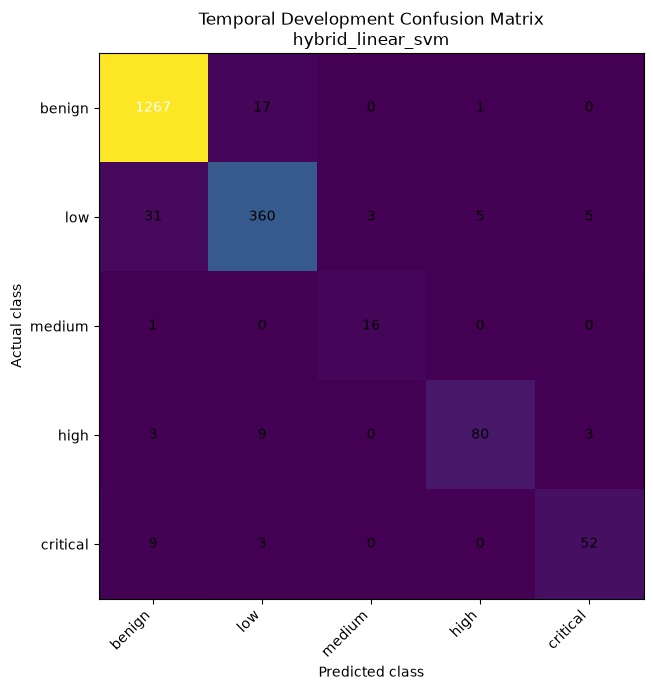

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\figures\best_baseline_confusion_matrix.png


In [24]:
plt.figure(figsize=(9, 7))

plt.imshow(
    best_confusion_matrix,
    interpolation="nearest",
)

plt.title(
    f"Temporal Development Confusion Matrix\n"
    f"{best_baseline_name}"
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.xticks(
    np.arange(len(CLASS_ORDER)),
    CLASS_ORDER,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(len(CLASS_ORDER)),
    CLASS_ORDER,
)

maximum_matrix_value = (
    best_confusion_matrix.max()
    if best_confusion_matrix.size
    else 0
)

threshold = maximum_matrix_value / 2.0

for row_index in range(
    best_confusion_matrix.shape[0]
):
    for column_index in range(
        best_confusion_matrix.shape[1]
    ):
        matrix_value = (
            best_confusion_matrix[
                row_index,
                column_index,
            ]
        )

        plt.text(
            column_index,
            row_index,
            str(matrix_value),
            ha="center",
            va="center",
            color=(
                "white"
                if matrix_value > threshold
                else "black"
            ),
        )

plt.tight_layout()

confusion_matrix_figure_path = (
    FIGURES_DIR
    / "best_baseline_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    confusion_matrix_figure_path,
)

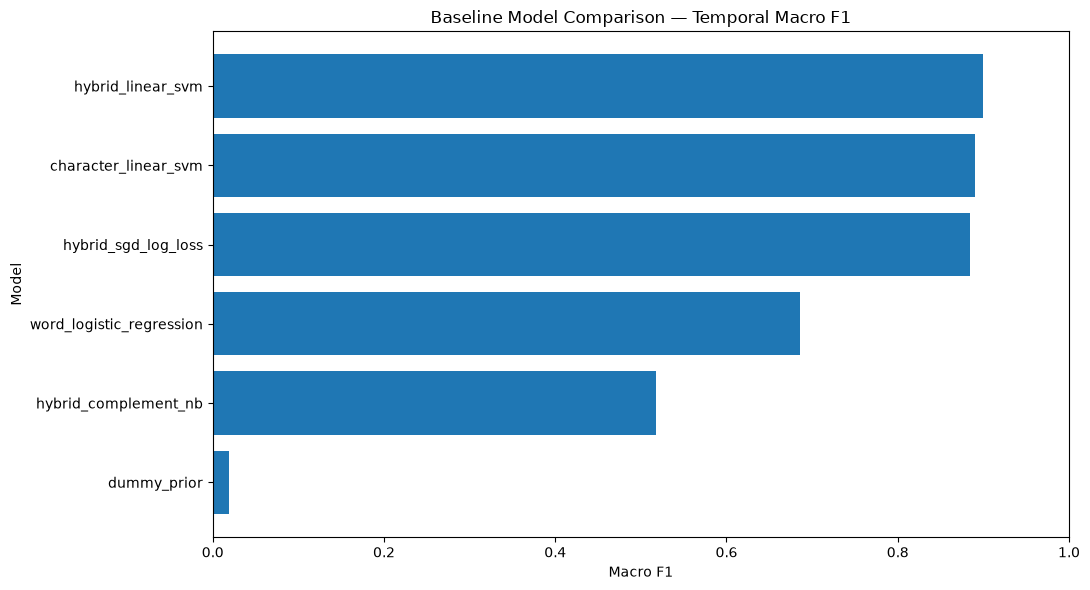

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\figures\baseline_macro_f1_comparison.png


In [25]:
plot_results = (
    baseline_results
    .sort_values(
        "macro_f1",
        ascending=True,
    )
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_results["model"],
    plot_results["macro_f1"],
)

plt.title(
    "Baseline Model Comparison — Temporal Macro F1"
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.xlim(
    0,
    max(
        1.0,
        plot_results[
            "macro_f1"
        ].max()
        * 1.10,
    ),
)

plt.tight_layout()

model_comparison_figure_path = (
    FIGURES_DIR
    / "baseline_macro_f1_comparison.png"
)

plt.savefig(
    model_comparison_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    model_comparison_figure_path,
)

In [26]:
best_prediction_output = (
    temporal_development_data[
        [
            "diff_id",
            "repository",
            "commit_hash",
            "commit_author_date",
            "file_path",
            "configuration_type",
            "parser_mode",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "training_target",
            "sample_weight",
        ]
    ]
    .copy()
)

best_prediction_output[
    "predicted_label"
] = best_baseline_predictions

best_prediction_output[
    "prediction_correct"
] = (
    best_prediction_output[
        "training_target"
    ]
    == best_prediction_output[
        "predicted_label"
    ]
)

best_score_matrix = (
    baseline_score_matrices[
        best_baseline_name
    ]
)

if best_score_matrix is not None:
    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        best_prediction_output[
            f"score_{class_name}"
        ] = best_score_matrix[
            :,
            class_index,
        ]

print(
    "Prediction output rows:",
    f"{len(best_prediction_output):,}",
)

display(best_prediction_output.head())

Prediction output rows: 1,865


,diff_id,repository,commit_hash,commit_author_date,file_path,configuration_type,parser_mode,operation,field_path,old_value,new_value,training_target,sample_weight,predicted_label,prediction_correct,score_benign,score_low,score_medium,score_high,score_critical
0,5312313a6a8671e134373e039b11e7051bf292e43aa6162ca76a21c07f99929c,kube_prometheus,760b786b29edb4aa917e87746cb9e2cab9cf3066,2025-09-15T10:37:32+02:00,manifests/setup/0servicemonitorCustomResourceDefinition.yaml,yaml,structured,modified,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.endpoints.items.properties.filterRunning.description,"When true, the pods which are not running (e.g. either in Failed or\nSucceeded state) are dropped during the target discovery.\n\nIf unset, the filtering is enabled.\n\nMore info: https://kubernetes.io/docs/concepts/workloads/pods/pod-lifecycle/#pod-phase","filterRunning when true, the pods which are not running (e.g. either in Failed or\nSucceeded state) are dropped during the target discovery.\n\nIf unset, the filtering is enabled.\n\nMore info: https://kubernetes.io/docs/concepts/workloads/pods/pod-lifecycle/#pod-phase",low,1.255671,low,True,-0.436338,-0.313238,-1.666805,-0.519342,-1.077425
1,f56009fd0c56e99cbefde963be7533ee48cb222ea2db1c806114f6403f21b896,microservices_demo,18f3b732934abd656dc013bac7327a95c762b21c,2025-11-26T11:57:37-05:00,release/kubernetes-manifests.yaml,kubernetes,structured,modified,$.documents[19].spec.template.spec.containers[0].livenessProbe.grpc.port,7070,8080,low,1.255671,low,True,-1.460842,1.537935,-2.776774,-1.808528,-1.661594
2,4363d09488d6d823688af9d432a3ca91ca73de992902ef6f4f976e570b43e107,microservices_demo,12b18767d5d7505aef4fe88b9ed3c9adbd4fd335,2025-07-24T19:38:03-04:00,src/currencyservice/package-lock.json,json,structured,added,$.packages.node_modules/call-bind-apply-helpers.resolved,NaN,https://registry.npmjs.org/call-bind-apply-helpers/-/call-bind-apply-helpers-1.0.2.tgz,high,9.600000,low,False,-0.991611,0.017236,-2.006383,-0.150964,-1.221996
3,2ecd8afa3913089561843c31d64520e2dc94eb220bda337bac8299c5f089a959,microservices_demo,7cfba453a014340f66c4b4963adfc0718858fd91,2025-05-29T21:56:03+03:00,helm-chart/values.yaml,helm,structured,modified,$.cartService.resources.limits.memory,128Mi,256Mi,low,1.255671,medium,False,-2.469260,0.214391,0.329288,-2.055049,-1.058484
4,d2bb2e68d4656d2a8873d6838d9d2616ea03d8d6d3cba2604db4a021a92d753b,microservices_demo,abf56c68cee6d201e2b7f00e5848d49398a12de7,2025-10-14T15:38:39+01:00,src/paymentservice/package-lock.json,json,structured,deleted,$.dependencies.is-core-module.version,2.13.0,NaN,benign,0.206497,benign,True,1.230494,-1.359196,-1.310645,-2.040180,-1.480975


In [27]:
misclassified_records = (
    best_prediction_output[
        ~best_prediction_output[
            "prediction_correct"
        ]
    ]
    .copy()
)

error_transition_summary = (
    misclassified_records
    .groupby(
        [
            "training_target",
            "predicted_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
    .sort_values(
        "records",
        ascending=False,
    )
)

print(
    "Misclassified records:",
    f"{len(misclassified_records):,}",
)

display(error_transition_summary.head(30))

error_transition_summary.to_csv(
    TABLES_DIR
    / "best_baseline_error_transitions.csv",
    index=False,
)

Misclassified records: 90


,training_target,predicted_label,records
7,low,benign,31
1,benign,low,17
6,high,low,9
2,critical,benign,9
9,low,high,5
8,low,critical,5
4,high,benign,3
3,critical,low,3
10,low,medium,3
5,high,critical,3


In [30]:
critical_mask = (
    best_prediction_output[
        "training_target"
    ].eq("critical")
)

critical_record_count = int(
    critical_mask.sum()
)

critical_false_negatives = (
    best_prediction_output[
        critical_mask
        &
        ~best_prediction_output[
            "predicted_label"
        ].eq("critical")
    ]
    .copy()
)

critical_false_negative_summary = (
    critical_false_negatives[
        "predicted_label"
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis("predicted_label")
    .reset_index(name="records")
)

print(
    "Critical records in temporal dev:",
    f"{critical_record_count:,}",
)

print(
    "Critical false negatives:",
    f"{len(critical_false_negatives):,}",
)

display(critical_false_negative_summary)

display(
    critical_false_negatives[
        [
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "predicted_label",
        ]
    ].head(20)
)

Critical records in temporal dev: 64
Critical false negatives: 12


,predicted_label,records
0,benign,9
1,low,3
2,medium,0
3,high,0
4,critical,0


,repository,configuration_type,operation,field_path,old_value,new_value,predicted_label
56,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.endpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,benign
101,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.oauth2.properties.tokenUrl.minLength,1,NaN,benign
139,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.podMetricsEndpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,benign
150,microservices_demo,json,deleted,$.packages.node_modules/google-auth-library/node_modules/gaxios.resolved,https://registry.npmjs.org/gaxios/-/gaxios-5.1.3.tgz,NaN,low
587,kube_prometheus,yaml,added,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.volumes.items.properties.rbd.properties.user.default,NaN,admin,benign
759,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.web.properties.tlsConfig.required[0],cert,NaN,benign
1407,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.alertmanagerConfiguration.properties.global.properties.httpConfig.properties.oauth2.properties.tokenUrl.minLength,1,NaN,low
1410,microservices_demo,json,deleted,$.packages.node_modules/google-auth-library/node_modules/gcp-metadata.resolved,https://registry.npmjs.org/gcp-metadata/-/gcp-metadata-5.3.0.tgz,NaN,low
1478,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.httpSDConfigs.items.properties.proxyConnectHeader.additionalProperties.required[0],key,NaN,benign
1737,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.remoteWrite.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,benign


In [31]:
actual_high_critical = (
    best_prediction_output[
        "training_target"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

predicted_high_critical = (
    best_prediction_output[
        "predicted_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

high_critical_false_negatives = (
    best_prediction_output[
        actual_high_critical
        & ~predicted_high_critical
    ]
    .copy()
)

high_critical_false_positives = (
    best_prediction_output[
        ~actual_high_critical
        & predicted_high_critical
    ]
    .copy()
)

print(
    "High/critical false negatives:",
    f"{len(high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(high_critical_false_positives):,}",
)

display(
    high_critical_false_negatives[
        [
            "training_target",
            "predicted_label",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
        ]
    ].head(20)
)

High/critical false negatives: 24
High/critical false positives: 11


,training_target,predicted_label,configuration_type,operation,field_path,old_value,new_value
2,high,low,json,added,$.packages.node_modules/call-bind-apply-helpers.resolved,NaN,https://registry.npmjs.org/call-bind-apply-helpers/-/call-bind-apply-helpers-1.0.2.tgz
56,critical,benign,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.endpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN
101,critical,benign,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.oauth2.properties.tokenUrl.minLength,1,NaN
139,critical,benign,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.podMetricsEndpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN
150,critical,low,json,deleted,$.packages.node_modules/google-auth-library/node_modules/gaxios.resolved,https://registry.npmjs.org/gaxios/-/gaxios-5.1.3.tgz,NaN
387,high,low,yaml,modified,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.remoteWrite.items.properties.roundRobinDNS.description,"When enabled:\n - The remote-write mechanism will resolve the hostname via DNS.\n - It will randomly select one of the resolved IP addresses and connect to it.\n\nWhen disabled (default behavior):\n - The Go standard library will handle hostname resolution.\n - It will attempt connections to each resolved IP address sequentially.\n\nNote: The connection timeout applies to the entire resolution and connection process.\n If disabled, the timeout is distributed across all conne...","When enabled:\n - The remote-write mechanism will resolve the hostname via DNS.\n - It will randomly select one of the resolved IP addresses and connect to it.\n\nWhen disabled (default behavior):\n - The Go standard library will handle hostname resolution.\n - It will attempt connections to each resolved IP address sequentially.\n\nNote: The connection timeout applies to the entire resolution and connection process.\n If disabled, the timeout is distributed across all conne..."
438,high,benign,yaml,added,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.remoteWrite.items.properties.roundRobinDNS.description,NaN,"When enabled:\n - The remote-write mechanism will resolve the hostname via DNS.\n - It will randomly select one of the resolved IP addresses and connect to it.\n\nWhen disabled (default behavior):\n - The Go standard library will handle hostname resolution.\n - It will attempt connections to each resolved IP address sequentially.\n\nNote: The connection timeout applies to the entire resolution and connection process.\n If disabled, the timeout is distributed across all conne..."
568,high,low,terraform,added,$.variable security_group_rules[0].type[0],NaN,any
587,critical,benign,yaml,added,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.volumes.items.properties.rbd.properties.user.default,NaN,admin
635,high,low,terraform,added,$.module wrapper[0].public_subnet_private_dns_hostname_type_on_launch[0],NaN,"try(each.value.public_subnet_private_dns_hostname_type_on_launch, var.defaults.public_subnet_private_dns_hostname_type_on_launch, null)"


In [32]:
repository_metric_records = []

for repository_name, repository_data in (
    best_prediction_output.groupby(
        "repository"
    )
):
    repository_metric_records.append(
        {
            "repository":
                repository_name,
            "records":
                len(repository_data),
            "commits":
                repository_data[
                    "commit_hash"
                ].nunique(),
            "accuracy": float(
                accuracy_score(
                    repository_data[
                        "training_target"
                    ],
                    repository_data[
                        "predicted_label"
                    ],
                )
            ),
            "balanced_accuracy": float(
                balanced_accuracy_score(
                    repository_data[
                        "training_target"
                    ],
                    repository_data[
                        "predicted_label"
                    ],
                )
            ),
            "macro_f1": float(
                f1_score(
                    repository_data[
                        "training_target"
                    ],
                    repository_data[
                        "predicted_label"
                    ],
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

repository_metrics = pd.DataFrame(
    repository_metric_records
)

display(
    repository_metrics.sort_values(
        "macro_f1",
        ascending=False,
    )
)

repository_metrics.to_csv(
    TABLES_DIR
    / "best_baseline_repository_metrics.csv",
    index=False,
)

,repository,records,commits,accuracy,balanced_accuracy,macro_f1
1,microservices_demo,959,129,0.977059,0.964053,0.955367
2,terraform_aws_vpc,238,34,0.890756,0.826741,0.604570
0,kube_prometheus,668,103,0.937126,0.579545,0.598518


In [33]:
configuration_metric_records = []

for configuration_type, configuration_data in (
    best_prediction_output.groupby(
        "configuration_type"
    )
):
    if len(configuration_data) < 10:
        continue

    configuration_metric_records.append(
        {
            "configuration_type":
                configuration_type,
            "records":
                len(configuration_data),
            "classes_present":
                configuration_data[
                    "training_target"
                ].nunique(),
            "accuracy": float(
                accuracy_score(
                    configuration_data[
                        "training_target"
                    ],
                    configuration_data[
                        "predicted_label"
                    ],
                )
            ),
            "macro_f1": float(
                f1_score(
                    configuration_data[
                        "training_target"
                    ],
                    configuration_data[
                        "predicted_label"
                    ],
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

configuration_type_metrics = (
    pd.DataFrame(
        configuration_metric_records
    )
)

display(
    configuration_type_metrics.sort_values(
        [
            "records",
            "macro_f1",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(30)
)

configuration_type_metrics.to_csv(
    TABLES_DIR
    / "best_baseline_configuration_type_metrics.csv",
    index=False,
)

,configuration_type,records,classes_present,accuracy,macro_f1
2,json,514,4,0.988327,0.587656
3,kubernetes,488,5,1.000000,1.000000
6,yaml,485,5,0.896907,0.531824
5,terraform,247,4,0.894737,0.602761
4,kustomize,101,1,1.000000,0.200000
1,helm,12,2,0.666667,0.301818
0,configuration,11,1,1.000000,0.200000


In [34]:
parser_metric_records = []

for parser_mode, parser_data in (
    best_prediction_output.groupby(
        "parser_mode"
    )
):
    parser_metric_records.append(
        {
            "parser_mode":
                parser_mode,
            "records":
                len(parser_data),
            "accuracy": float(
                accuracy_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                )
            ),
            "balanced_accuracy": float(
                balanced_accuracy_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                )
            ),
            "macro_f1": float(
                f1_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

parser_mode_metrics = pd.DataFrame(
    parser_metric_records
)

display(parser_mode_metrics)

parser_mode_metrics.to_csv(
    TABLES_DIR
    / "best_baseline_parser_mode_metrics.csv",
    index=False,
)

,parser_mode,records,accuracy,balanced_accuracy,macro_f1
0,structured,1865,0.951743,0.894573,0.899128


In [35]:
saved_model_paths = {}

for model_name, trained_model in (
    trained_baseline_models.items()
):
    model_path = (
        MODELS_DIR
        / f"{model_name}.joblib"
    )

    joblib.dump(
        trained_model,
        model_path,
        compress=3,
    )

    saved_model_paths[
        model_name
    ] = str(model_path)

    print(
        f"{model_name:<30}",
        "->",
        model_path.name,
    )

best_baseline_model_path = (
    MODELS_DIR
    / "best_baseline_model.joblib"
)

joblib.dump(
    best_baseline_model,
    best_baseline_model_path,
    compress=3,
)

print(
    "\nBest baseline model saved:",
    best_baseline_model_path,
)

dummy_prior                    -> dummy_prior.joblib
word_logistic_regression       -> word_logistic_regression.joblib
character_linear_svm           -> character_linear_svm.joblib
hybrid_linear_svm              -> hybrid_linear_svm.joblib
hybrid_sgd_log_loss            -> hybrid_sgd_log_loss.joblib
hybrid_complement_nb           -> hybrid_complement_nb.joblib

Best baseline model saved: C:\Users\Lenovo\Desktop\DriftGuard\models\baselines\best_baseline_model.joblib


In [36]:
baseline_results_path = (
    TABLES_DIR
    / "baseline_model_comparison.csv"
)

baseline_results.to_csv(
    baseline_results_path,
    index=False,
)

best_prediction_path = (
    PREDICTIONS_DIR
    / "best_baseline_temporal_predictions.csv.gz"
)

best_prediction_output.to_csv(
    best_prediction_path,
    index=False,
    compression="gzip",
)

critical_false_negative_path = (
    PREDICTIONS_DIR
    / "critical_false_negatives.csv.gz"
)

critical_false_negatives.to_csv(
    critical_false_negative_path,
    index=False,
    compression="gzip",
)

high_critical_false_negative_path = (
    PREDICTIONS_DIR
    / "high_critical_false_negatives.csv.gz"
)

high_critical_false_negatives.to_csv(
    high_critical_false_negative_path,
    index=False,
    compression="gzip",
)

training_error_path = (
    OUTPUTS_DIR
    / "baseline_training_errors.json"
)

with training_error_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_training_errors,
        file,
        indent=2,
    )

print("Saved model comparison :", baseline_results_path)
print("Saved predictions      :", best_prediction_path)
print("Saved critical errors  :", critical_false_negative_path)
print("Saved training errors  :", training_error_path)

Saved model comparison : C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\tables\baseline_model_comparison.csv
Saved predictions      : C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\predictions\best_baseline_temporal_predictions.csv.gz
Saved critical errors  : C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\predictions\critical_false_negatives.csv.gz
Saved training errors  : C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\baseline_training_errors.json


In [37]:
best_result_row = (
    baseline_results[
        baseline_results[
            "model"
        ].eq(best_baseline_name)
    ]
    .iloc[0]
)

baseline_integrity_checks = {
    "Model-training data is not empty":
        len(model_training_data) > 0,

    "Temporal-development data is not empty":
        len(temporal_development_data) > 0,

    "Model-training and development commits are disjoint":
        len(overlapping_commit_keys) == 0,

    "All five training classes exist":
        set(CLASS_ORDER).issubset(
            set(y_train)
        ),

    "All five development classes exist":
        set(CLASS_ORDER).issubset(
            set(y_development)
        ),

    "No target leakage feature is used":
        len(feature_leakage_overlap) == 0,

    "At least one non-dummy model succeeded":
        any(
            model_name != "dummy_prior"
            for model_name
            in trained_baseline_models
        ),

    "Best baseline is not the dummy model":
        best_baseline_name
        != "dummy_prior",

    "Prediction count matches temporal development":
        len(best_prediction_output)
        == len(temporal_development_data),

    "Predictions contain only valid labels":
        best_prediction_output[
            "predicted_label"
        ].isin(CLASS_ORDER).all(),

    "Macro F1 is finite":
        np.isfinite(
            best_result_row[
                "macro_f1"
            ]
        ),

    "Critical recall is finite":
        np.isfinite(
            best_result_row[
                "critical_recall"
            ]
        ),

    "Best model file exists":
        best_baseline_model_path.exists(),

    "Metrics file exists":
        baseline_results_path.exists(),

    "Prediction file exists":
        best_prediction_path.exists(),
}

print("Baseline integrity checks:\n")

for check_name, passed in (
    baseline_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_baseline_checks = [
    check_name
    for check_name, passed
    in baseline_integrity_checks.items()
    if not bool(passed)
]

print(
    "\nFailed integrity checks:",
    len(failed_baseline_checks),
)

Baseline integrity checks:

PASSED   | Model-training data is not empty
PASSED   | Temporal-development data is not empty
PASSED   | Model-training and development commits are disjoint
PASSED   | All five training classes exist
PASSED   | All five development classes exist
PASSED   | No target leakage feature is used
PASSED   | At least one non-dummy model succeeded
PASSED   | Best baseline is not the dummy model
PASSED   | Prediction count matches temporal development
PASSED   | Predictions contain only valid labels
PASSED   | Macro F1 is finite
PASSED   | Critical recall is finite
PASSED   | Best model file exists
PASSED   | Metrics file exists
PASSED   | Prediction file exists

Failed integrity checks: 0


In [38]:
best_baseline_metrics = {
    key: (
        None
        if pd.isna(value)
        else (
            float(value)
            if isinstance(
                value,
                (
                    np.floating,
                    float,
                ),
            )
            else (
                int(value)
                if isinstance(
                    value,
                    (
                        np.integer,
                        int,
                    ),
                )
                else value
            )
        )
    )
    for key, value
    in best_result_row.to_dict().items()
}

baseline_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "model_training_records":
        int(len(model_training_data)),

    "temporal_development_records":
        int(
            len(
                temporal_development_data
            )
        ),

    "training_commits":
        int(len(training_commit_keys)),

    "temporal_development_commits":
        int(
            len(
                development_commit_keys
            )
        ),

    "successful_models":
        sorted(
            trained_baseline_models.keys()
        ),

    "failed_models":
        baseline_training_errors,

    "best_baseline_model":
        best_baseline_name,

    "best_baseline_metrics":
        best_baseline_metrics,

    "best_model_path":
        str(
            best_baseline_model_path
        ),

    "feature_columns":
        BASELINE_RAW_FEATURE_COLUMNS,

    "forbidden_feature_columns":
        sorted(
            FORBIDDEN_FEATURE_COLUMNS
        ),

    "critical_false_negatives":
        int(
            len(
                critical_false_negatives
            )
        ),

    "high_critical_false_negatives":
        int(
            len(
                high_critical_false_negatives
            )
        ),

    "failed_integrity_checks":
        failed_baseline_checks,

    "all_integrity_checks_passed":
        len(
            failed_baseline_checks
        ) == 0,
}

baseline_summary_path = (
    OUTPUTS_DIR
    / "baseline_training_summary.json"
)

with baseline_summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_summary,
        file,
        indent=2,
    )

print(
    "Saved baseline summary:",
    baseline_summary_path,
)

Saved baseline summary: C:\Users\Lenovo\Desktop\DriftGuard\outputs\baseline_models\baseline_training_summary.json


In [39]:
print("=" * 72)
print("NOTEBOOK 07 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. DATASET USAGE")
print("-" * 72)

print(
    "Model-training records       :",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-development records :",
    f"{len(temporal_development_data):,}",
)

print(
    "Model-training commits       :",
    f"{len(training_commit_keys):,}",
)

print(
    "Temporal-development commits :",
    f"{len(development_commit_keys):,}",
)

print(
    "Overlapping commits          :",
    f"{len(overlapping_commit_keys):,}",
)

print("\n2. BASELINE MODEL RANKING")
print("-" * 72)

display(
    baseline_results[
        [
            "rank",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
        ]
    ]
)

print("\n3. BEST BASELINE")
print("-" * 72)

print(
    "Best model             :",
    best_baseline_name,
)

print(
    "Macro F1               :",
    f"{best_result_row['macro_f1']:.4f}",
)

print(
    "Balanced accuracy      :",
    f"{best_result_row['balanced_accuracy']:.4f}",
)

print(
    "Critical precision     :",
    f"{best_result_row['critical_precision']:.4f}",
)

print(
    "Critical recall        :",
    f"{best_result_row['critical_recall']:.4f}",
)

print(
    "High/critical precision:",
    f"{best_result_row['high_critical_precision']:.4f}",
)

print(
    "High/critical recall   :",
    f"{best_result_row['high_critical_recall']:.4f}",
)

print(
    "Macro PR-AUC           :",
    f"{best_result_row['macro_pr_auc']:.4f}",
)

print("\n4. BEST-MODEL PER-CLASS RESULTS")
print("-" * 72)

display(
    baseline_per_class_metrics[
        baseline_per_class_metrics[
            "model"
        ].eq(best_baseline_name)
    ][
        [
            "class",
            "support",
            "precision",
            "recall",
            "f1",
            "average_precision",
        ]
    ]
)

print("\n5. SAFETY-CRITICAL ERRORS")
print("-" * 72)

print(
    "Critical false negatives     :",
    f"{len(critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(high_critical_false_positives):,}",
)

print("\n6. TRAINING FAILURES")
print("-" * 72)

if baseline_training_errors:
    for model_name, error_details in (
        baseline_training_errors.items()
    ):
        print(
            model_name,
            "->",
            error_details[
                "error_type"
            ],
            ":",
            error_details[
                "error_message"
            ],
        )
else:
    print("No baseline models failed.")

print("\n7. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_baseline_checks:
    for index, check_name in enumerate(
        failed_baseline_checks,
        start=1,
    ):
        print(f"{index}. {check_name}")
else:
    print("No failed integrity checks.")
    print("All baseline integrity checks passed.")

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 07 — REQUIRED RESULTS

1. DATASET USAGE
------------------------------------------------------------------------
Model-training records       : 7,711
Temporal-development records : 1,865
Model-training commits       : 1,058
Temporal-development commits : 266
Overlapping commits          : 0

2. BASELINE MODEL RANKING
------------------------------------------------------------------------


,rank,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1
0,1,hybrid_linear_svm,0.951743,0.894573,0.899128,0.951146,0.916507,0.866667,0.812500,0.838710,0.924658,0.849057,0.885246
1,2,character_linear_svm,0.939410,0.889975,0.890051,0.939246,0.915170,0.825397,0.812500,0.818898,0.882353,0.849057,0.865385
2,3,hybrid_sgd_log_loss,0.941019,0.892732,0.884648,0.940741,0.946339,0.854839,0.828125,0.841270,0.882353,0.849057,0.865385
3,4,word_logistic_regression,0.806971,0.847350,0.685648,0.829295,0.896023,0.487603,0.921875,0.637838,0.351852,0.955975,0.514382
4,5,hybrid_complement_nb,0.578552,0.806578,0.517491,0.642279,0.823949,0.117537,0.984375,0.210000,0.211796,0.993711,0.349171
5,6,dummy_prior,0.050938,0.200000,0.019388,0.004938,0.200000,0.000000,0.000000,0.000000,0.085255,1.000000,0.157115



3. BEST BASELINE
------------------------------------------------------------------------
Best model             : hybrid_linear_svm
Macro F1               : 0.8991
Balanced accuracy      : 0.8946
Critical precision     : 0.8667
Critical recall        : 0.8125
High/critical precision: 0.9247
High/critical recall   : 0.8491
Macro PR-AUC           : 0.9165

4. BEST-MODEL PER-CLASS RESULTS
------------------------------------------------------------------------


,class,support,precision,recall,f1,average_precision
15,benign,1285,0.966438,0.985992,0.976117,0.995082
16,low,404,0.925450,0.891089,0.907945,0.949967
17,medium,17,0.842105,0.941176,0.888889,0.898024
18,high,95,0.930233,0.842105,0.883978,0.925016
19,critical,64,0.866667,0.812500,0.838710,0.814444



5. SAFETY-CRITICAL ERRORS
------------------------------------------------------------------------
Critical false negatives     : 12
High/critical false negatives: 24
High/critical false positives: 11

6. TRAINING FAILURES
------------------------------------------------------------------------
No baseline models failed.

7. FAILED INTEGRITY CHECKS
------------------------------------------------------------------------
No failed integrity checks.
All baseline integrity checks passed.

REQUIRED RESULTS GENERATED


In [40]:
print("=" * 72)
print("NOTEBOOK 07 COMPLETED")
print("=" * 72)

print(
    "Baseline models attempted:",
    len(BASELINE_MODELS),
)

print(
    "Successful models       :",
    len(trained_baseline_models),
)

print(
    "Failed models           :",
    len(baseline_training_errors),
)

print(
    "Best temporal baseline  :",
    best_baseline_name,
)

print(
    "Best macro F1           :",
    f"{best_result_row['macro_f1']:.4f}",
)

print(
    "Best critical recall    :",
    f"{best_result_row['critical_recall']:.4f}",
)

print(
    "Best high/critical recall:",
    f"{best_result_row['high_critical_recall']:.4f}",
)

print(
    "Critical false negatives:",
    f"{len(critical_false_negatives):,}",
)

print(
    "Model saved to          :",
    best_baseline_model_path,
)

print("\nImportant:")
print("- These are weak-label temporal-development results.")
print("- They are not final repository-disjoint test metrics.")
print("- Validation and test repositories were not used.")
print("- Rule identifiers and label explanations were excluded from features.")
print("- Macro F1 determined the baseline ranking.")
print("- Critical recall remains a mandatory safety metric.")
print("- Notebook 08 will train structured-feature ML models.")

print("\nNext notebook:")
print("08_train_structured_ml_models.ipynb")

NOTEBOOK 07 COMPLETED
Baseline models attempted: 6
Successful models       : 6
Failed models           : 0
Best temporal baseline  : hybrid_linear_svm
Best macro F1           : 0.8991
Best critical recall    : 0.8125
Best high/critical recall: 0.8491
Critical false negatives: 12
Model saved to          : C:\Users\Lenovo\Desktop\DriftGuard\models\baselines\best_baseline_model.joblib

Important:
- These are weak-label temporal-development results.
- They are not final repository-disjoint test metrics.
- Validation and test repositories were not used.
- Rule identifiers and label explanations were excluded from features.
- Macro F1 determined the baseline ranking.
- Critical recall remains a mandatory safety metric.
- Notebook 08 will train structured-feature ML models.

Next notebook:
08_train_structured_ml_models.ipynb
